In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import networkx as nx
import os
import re
import matplotlib.pyplot as plt

sc.set_figure_params(dpi=80)

import seaborn as sns
plt.rcParams['axes.grid'] = False

import matplotlib
from matplotlib.gridspec import GridSpec
from datetime import datetime
from matplotlib.ticker import FixedLocator, FixedFormatter
from tqdm import tqdm
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))

from plotting_functions import make_density_map_simple, make_density_map


In [ ]:
adata = sc.read_h5ad('../data/Reyes_FLEX_SUBSET_TAM_all__integrated.h5ad')
obs = pd.read_csv('../data/Reyes_FLEX_SUBSET_TAM_all__integrated.csv', index_col = 0)
adata.obs = obs.copy()

In [ ]:
adata.var_names = [x.capitalize() for x in adata.var_names]

In [ ]:
df = pd.read_csv('../differential_expression/DXP20250427_QUERY_TAM_Cd274_vs_REFERENCE_TAM_Itgax_SIZEFACTOR_True_BATCH_False.csv', index_col = 0)
df = df.iloc[np.argsort(df['log2fc'])[::-1],:].copy()
df = df.loc[df['mean'] > 1,:].copy()
df = df.loc[np.abs(df['log2fc']) < 10,:].copy()
df

,gene,pval,qval,log2fc,mean,zero_mean,grad,coef_mle,coef_sd,ll
76,CAR4,0.0,0.0,4.418705,2.533916,False,1.904439e-08,4.418705,0.144950,-3755.052095
7206,CHIL3,0.0,0.0,4.121756,18.886808,False,2.436643e-08,4.121756,0.060002,-7209.345151
8340,FPR2,0.0,0.0,2.848105,1.361631,False,7.207632e-09,2.848105,0.095124,-3188.656350
1868,NET1,0.0,0.0,2.235435,1.595089,False,2.452431e-10,2.235435,0.069304,-3567.244507
6868,IL18,0.0,0.0,1.973527,1.294632,False,1.099799e-10,1.973527,0.069278,-3326.240477
...,...,...,...,...,...,...,...,...,...,...
6322,C1QB,0.0,0.0,-1.201218,3.358718,False,2.910062e-09,-1.201218,0.062628,-5197.343574
6316,C1QA,0.0,0.0,-1.229667,3.158136,False,1.277780e-08,-1.229667,0.066793,-5003.570973
6320,C1QC,0.0,0.0,-1.260614,1.531835,False,1.040671e-08,-1.260614,0.071595,-3706.195263
329,APOE,0.0,0.0,-1.971619,5.914274,False,7.664119e-08,-1.971619,0.087634,-5211.998868


In [ ]:
top_ten_genes = ['Cd274', 'Arg1', 'Spp1', 'Marco', 'Plaur', 'Dapk1', 'Il1rn', 'Serpine1', 'Cdkn2a', 'Il1b'] + df['gene'][:10].to_list()
bottom_genes = df['gene'][-10:].to_list()[::-1]
selected_genes = top_ten_genes + bottom_genes
selected_genes = [x.capitalize() for x in selected_genes]

In [ ]:
adata_sub = adata[np.isin(adata.obs['cell_type'], ['TAM_Cd274', 'TAM_Itgax']),:].copy()

/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/data/lowe/reyesj3/miniconda3/envs/rapidsai/lib/python3.9/site-packages/anndata/_core/anndata.py:1301: ImplicitModificationWarni

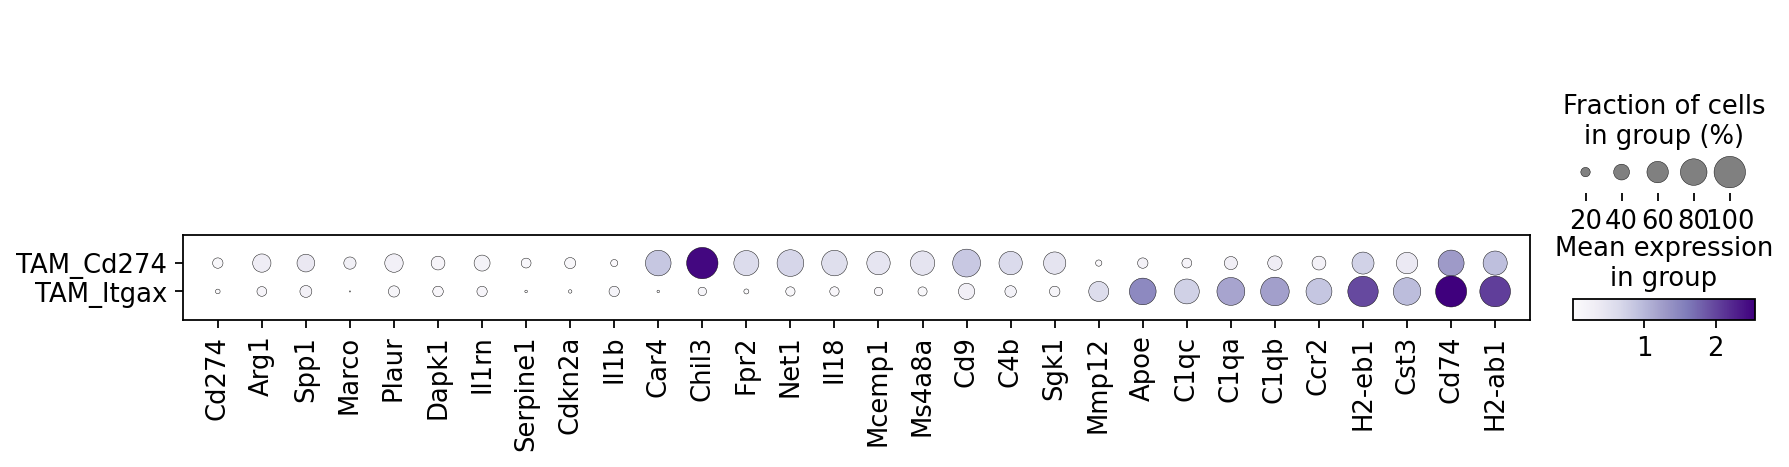

In [ ]:
sc.pl.dotplot(
    adata_sub[adata_sub.obs['cell_type']!='other',:], 
    groupby = 'cell_type', var_names = selected_genes, 
    cmap = 'Purples')

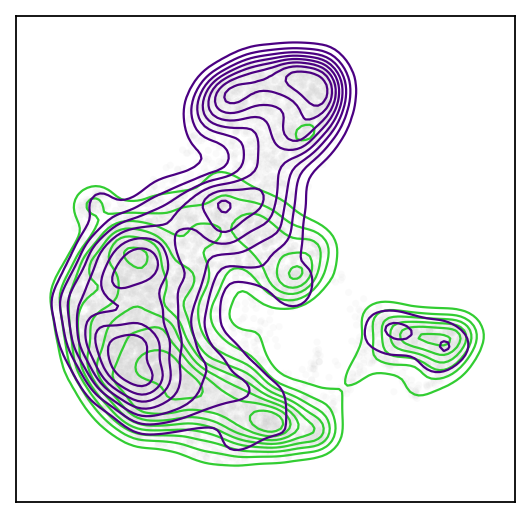

In [ ]:
plt.scatter(adata.obsm['X_umap'][:,0], adata.obsm['X_umap'][:,1], c = 'lightgray', edgecolor='none', s = 10, alpha = 0.1)

h = make_density_map(
    adata, adata.obs['condition'] == 'K3ctrl', 
    'X_umap', selected_contours = 10, 
    foreground_color = 'limegreen', gaussian_sigma = 3)

h = make_density_map(
    adata, adata.obs['condition'] == 'K3shp53', 
    'X_umap', selected_contours = 10, 
    foreground_color = 'indigo', gaussian_sigma = 3)